In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import pickle
import os
from src.rset_app import *
from src.rset_opt import *
from sklearn.linear_model import LogisticRegression
import torch
import random
import time

In [2]:
with open("compas_0.0005_0.001_1.01_merge_bins_15.p", "rb") as f:
    out = pickle.load(f)

In [3]:
with open("compas_0.0005_0.001_1.01.p", "rb") as f:
    res = pickle.load(f)

In [4]:
print("number of different support sets:", len(out["indices"]))

number of different support sets: 75


In [5]:
# find the first support set

# out["indices"][i] stores bins that need to be merged for support i
print(out["indices"][0])

[[12, 14]]


In [6]:
for i in out["indices"][0]:
    print([res["header_new"][k] for k in i])

['1.0<priors_count<=2.0', '5.0<priors_count<=8.0']


Based on the output above, `20.0<age<=22.0` and `22.0<age<=27.0` should be merged, and `priors_count<=0.0` and `0.0<priors_count<=1.0` should be merged. Therefore, the new support set is 

In [7]:
idx = 0
for i in out["indices"][0]:
    print(res["header_new"][idx:i[0]])
    print("merge bins", res["header_new"][i[0]:i[1]+1])
    idx = i[1]+1
print(res["header_new"][i[1]+1:])

['intercept', 'sex=female<=0.0', '0.0<sex=female<=1', 'age<=19.0', '19.0<age<=20.0', '20.0<age<=22.0', '22.0<age<=27.0', '27.0<age<=33.0', '33.0<age<=52.0', '52.0<age<=96', 'priors_count<=0.0', '0.0<priors_count<=1.0']
merge bins ['1.0<priors_count<=2.0', '2.0<priors_count<=5.0', '5.0<priors_count<=8.0']
['8.0<priors_count<=15.0', '15.0<priors_count<=38']


In [8]:
# Given this support set, its Rashomon set parameters are 
out["hessian_block"][0].shape

(15, 15)

In [9]:
print(out["w_center_block"][0].shape)
out["w_center_block"][0]

(15,)


array([-0.09995919,  0.06099323, -0.22900216,  2.61245335,  1.57218917,
        0.78921329,  0.28561587,  0.04769719, -0.42584426, -0.8830646 ,
       -0.83478387, -0.46810276,  0.33446411,  1.17718419,  1.73634936])

In [10]:
# following sampling function is slightly different from the one in rset_opt.py
def sample_in_subset_ellipsoid(H, w, ub, n_samples):
    d = w.shape[0]
    u = np.random.normal(size=(n_samples,d)) # randomly sample iid gaussian
    u = u/(np.linalg.norm(u,axis=1).reshape(-1,1)) # normalize to get uniformly random unit vectors
    r = (np.random.random(size=n_samples))**(1/d) # sample radius (uniformly in a sphere)
    x_ = u * r.reshape(-1,1) # x_ is a uniformly random point in a sphere
    
    lamb, V = np.linalg.eigh(H) # eigen decomposition
    a = np.sqrt(ub/lamb) # scaling factor
    dw_samples = ((a*V) @ x_.T).T # transformation to a ellipsoid
    w_samples = dw_samples + w

    return w_samples

In [11]:
import re

for col_name in res['header_new']:
    print(col_name)
    m = re.match(r"(?:(.*)<)?(.*)<=(.*)", col_name)
    if m:
        print(m.groups())

intercept
sex=female<=0.0
(None, 'sex=female', '0.0')
0.0<sex=female<=1
('0.0', 'sex=female', '1')
age<=19.0
(None, 'age', '19.0')
19.0<age<=20.0
('19.0', 'age', '20.0')
20.0<age<=22.0
('20.0', 'age', '22.0')
22.0<age<=27.0
('22.0', 'age', '27.0')
27.0<age<=33.0
('27.0', 'age', '33.0')
33.0<age<=52.0
('33.0', 'age', '52.0')
52.0<age<=96
('52.0', 'age', '96')
priors_count<=0.0
(None, 'priors_count', '0.0')
0.0<priors_count<=1.0
('0.0', 'priors_count', '1.0')
1.0<priors_count<=2.0
('1.0', 'priors_count', '2.0')
2.0<priors_count<=5.0
('2.0', 'priors_count', '5.0')
5.0<priors_count<=8.0
('5.0', 'priors_count', '8.0')
8.0<priors_count<=15.0
('8.0', 'priors_count', '15.0')
15.0<priors_count<=38
('15.0', 'priors_count', '38')


In [12]:
print(res['X'][2])
print(res['header_new'])

[1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
['intercept', 'sex=female<=0.0', '0.0<sex=female<=1', 'age<=19.0', '19.0<age<=20.0', '20.0<age<=22.0', '22.0<age<=27.0', '27.0<age<=33.0', '33.0<age<=52.0', '52.0<age<=96', 'priors_count<=0.0', '0.0<priors_count<=1.0', '1.0<priors_count<=2.0', '2.0<priors_count<=5.0', '5.0<priors_count<=8.0', '8.0<priors_count<=15.0', '15.0<priors_count<=38']


['intercept' 'sex=female<=0.0' '0.0<sex=female<=1' 'age<=19.0'
 '19.0<age<=20.0' '20.0<age<=22.0' '22.0<age<=27.0' '27.0<age<=33.0'
 '33.0<age<=52.0' '52.0<age<=96' 'priors_count<=0.0'
 '0.0<priors_count<=1.0' 'priors_count<=8.0' '8.0<priors_count<=15.0'
 '15.0<priors_count<=38']


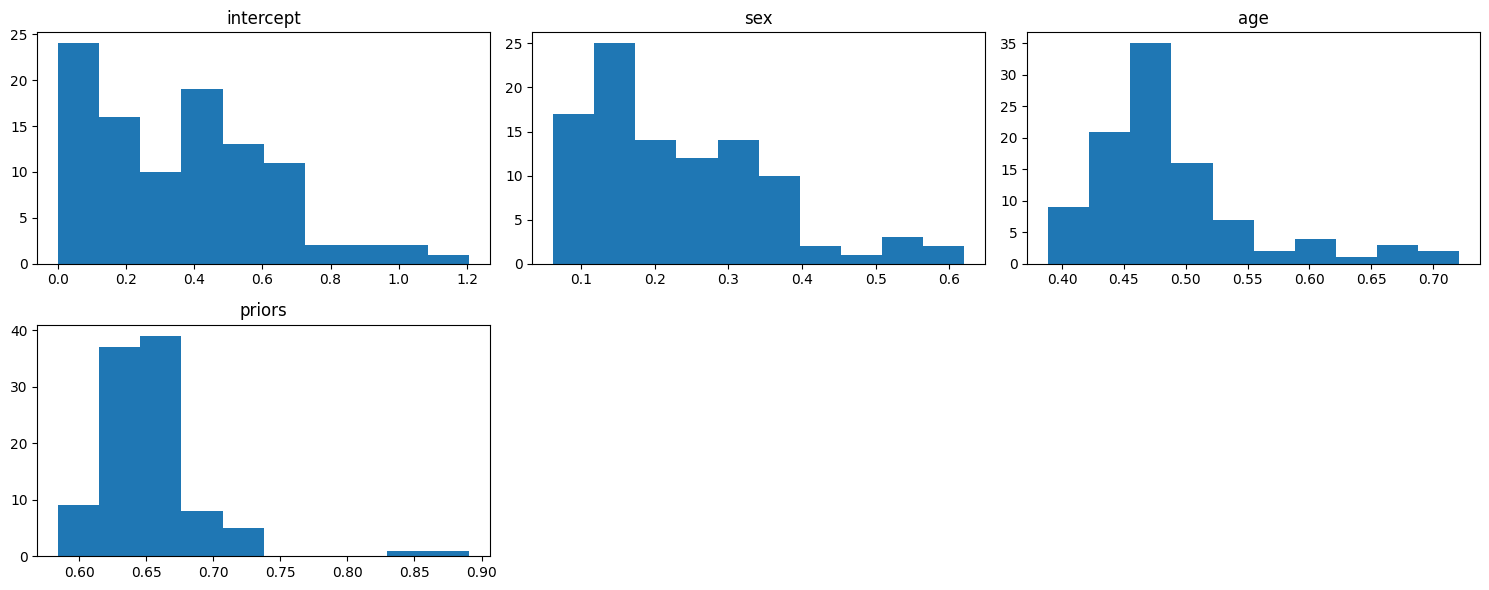

In [13]:
from gam_rs_utils.utils import *
import re

support = 0
X = res['X']

w_samples = sample_in_subset_ellipsoid(out["hessian_block"][support], 
                                       out["w_center_block"][support], 
                                       out["ub_block"][support], 
                                       n_samples=100)

new_X = []
col_pointer = 0
for i, j in out['indices'][support]:
    if i > col_pointer:
        new_X.append(X[:, col_pointer:i])
    merged = np.max(X[:, i:j+1], axis=1, keepdims=True)
    new_X.append(merged)
    col_pointer = j + 1
if col_pointer < X.shape[1]:
    new_X.append(X[:, col_pointer:])
new_X = np.hstack(new_X)

regex = r"(?:(.*)<)?(.*)<=(.*)"
header = res['header_new']
new_header = []
col_pointer = 0
for i, j in out['indices'][support]:
    if i > col_pointer:
        new_header.extend(header[col_pointer:i])
    start, feature, _ = re.match(regex, header[i]).groups()
    _, _, end = re.match(regex, header[j]).groups()
    new_header.append(f"{feature}<={end}" if start is not None else f"{feature}<={end}")
    col_pointer = j + 1
if col_pointer < len(header):
    new_header.extend(header[col_pointer:])
new_header = np.array(new_header)
print(new_header)

feature_to_vi = get_variable_importance(new_X, w_samples, new_header, True)
plot_variable_importance(feature_to_vi)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 15551.74it/s]


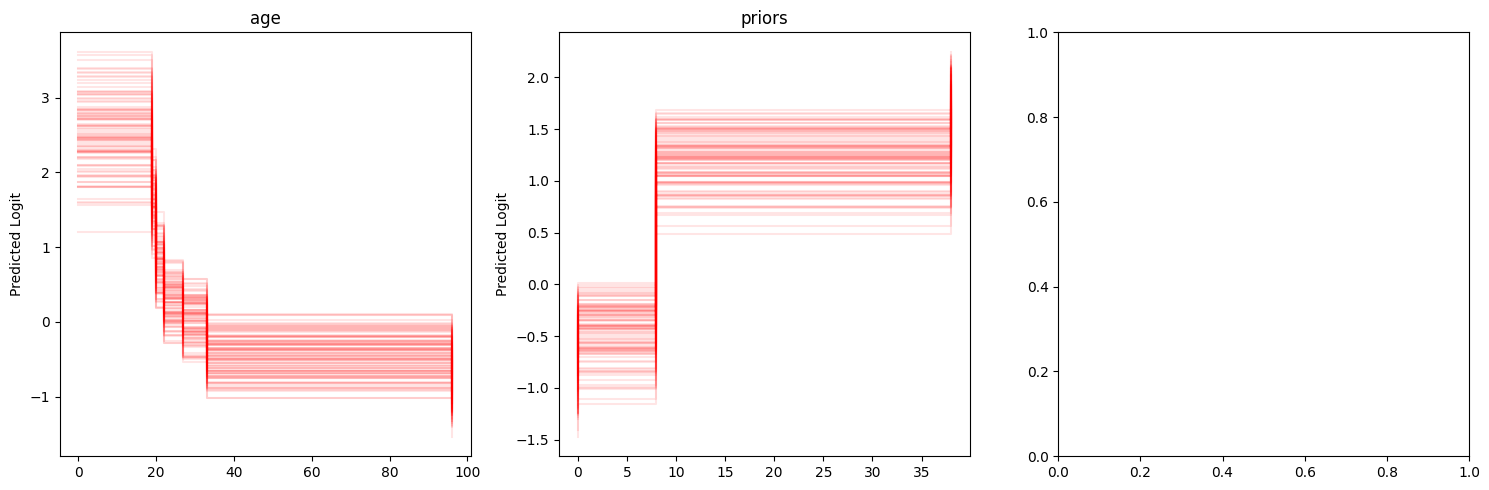

defaultdict(int,
            {'sex=female<=0.0': 100,
             '0.0<sex=female<=1': 100,
             'age<=19.0': 100,
             '19.0<age<=20.0': 100,
             '20.0<age<=22.0': 100,
             '22.0<age<=27.0': 100,
             '27.0<age<=33.0': 100,
             '33.0<age<=52.0': 100,
             '52.0<age<=96': 100,
             'priors_count<=0.0': 100,
             '0.0<priors_count<=1.0': 100,
             'priors_count<=8.0': 100,
             '8.0<priors_count<=15.0': 100,
             '15.0<priors_count<=38': 100})

In [14]:
plot_gam(new_header[1:], w_samples[:, 1:])

In [15]:
print(feature_to_vi)

defaultdict(<class 'list'>, {'intercept': [0.5083214370006958, 0.5910534481803797, 0.01711964923735658, 1.0053401495049459, 0.48832339433746696, 0.050703505031065736, 0.08736535211475194, 1.0095648301133204, 0.0910631278438149, 0.2206082878968223, 0.6597019820288857, 0.10299210263232725, 0.5290170781926975, 0.03337028303774309, 0.42708900745275313, 0.0691939404944178, 7.819396718375393e-05, 0.377627765912024, 0.36484155078131597, 0.04833627527580676, 1.2072800770302468, 0.13070509181346557, 0.2977609961897347, 0.6349556715268267, 0.17670879716168386, 0.864354502604957, 0.45789008752743793, 0.11606281152125819, 0.15237649159402372, 0.6827164180037363, 0.40478921351260394, 0.05130429537146347, 0.4286476983801024, 0.019680458259178663, 0.4526011290275971, 0.23729894497666987, 0.8884391612210959, 0.6830950153701864, 0.04787587021651055, 0.3735193287063524, 0.09668430502540676, 0.654555804632805, 0.3747218218452571, 0.8067468678650526, 0.16427710529831585, 0.049945118171722314, 0.4598378837